# Sample script for plotting 2D/3D trajectories

## Required packages

- numpy
- matplotlib
- cartopy
- pygmt
- imageio
- tqdm

In [1]:
from datetime import datetime, timedelta
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path
import pygmt
import tempfile
import imageio.v2 as imageio
from tqdm import tqdm
from IPython.display import HTML

from bsod2 import Sonde

## Read observational data and perform quality control.

In [2]:
# station name and sonde number mapping based on the field book.
# Note that the station name (e.g., "St.4a") is only for labeling the plot and is not used for QC.
# The sonde number is used to identify the corresponding data file.

field_book = {
        "St.4a": "1101771",
        "St.4b": "1101323",
        "St.4c": "1101386",
        "St.4d": "1101322",
        "St.4e": "1101327",
        "St.4f": "1101772",
        "St.4g": "1101388",
        "St.4h": "1101326",
    }

raw_data_dir = Path("Seisuimaru2407/raw_data")  # raw data directory

data = {}
for st_name, sonde_no in field_book.items():
    fpath = next(raw_data_dir.glob(f"F*S{sonde_no}.CSV"))
    data[st_name] = [Sonde(fpath)]

# assign colors for each station for plotting.
for i,st_name in enumerate(data.keys()):
    data[st_name].append(plt.rcParams['axes.prop_cycle'].by_key()['color'][i])

## plot settings

In [3]:
LON_MIN, LON_MAX = 136.0, 138.0     # longitude range for the plot
LON_TICKS = np.arange(135.5, 138.6, 0.5)    # longitude ticks for the plot
LAT_MIN, LAT_MAX = 34.0, 35.5   # latitude range for the plot
LAT_TICKS = np.arange(34.0, 35.6, 0.5)   # latitude ticks for the plot
Z_MIN, Z_MAX = -1000, 18000 # altitude range for the plot
Z_TICKS = np.arange(0, 18001, 2000)  # altitude ticks for the plot
AZIMUTH = 150  # 180 : north up
ELEV = 25

## Plot 2D trajectories colored by relative humidity.

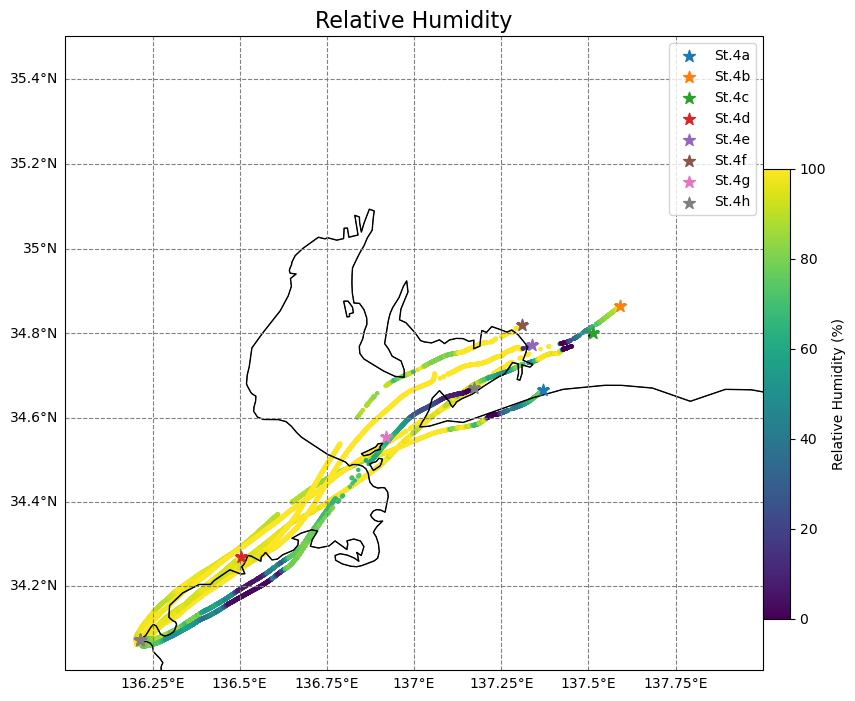

In [4]:
fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(
    1,
    1,
    1,
    projection=ccrs.Mercator(
        central_longitude=(LON_MAX - LON_MIN) / 2.0,
        min_latitude=LAT_MIN,
        max_latitude=LAT_MAX,
    ),
)
ax.set_title("Relative Humidity",fontsize=16)
ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX])
gl = ax.gridlines(
        crs=ccrs.PlateCarree(), color="gray", linestyle="--", draw_labels=True
    )
gl.top_labels = False
gl.right_labels = False

ax.add_feature(cfeature.COASTLINE, linewidth=0.5, linestyle="-")
ax.coastlines(color="k", linestyle="-")

for st_name, [sonde, color] in data.items():
    # plot the trajectory colored by relative humidity (rh).
    sc = ax.scatter(
        sonde.lon,
        sonde.lat,
        c=sonde.rh,
        s=5,
        transform=ccrs.PlateCarree(),
        vmin=0,
        vmax=100,
    )

    # mark the start and end points of the trajectory with a star marker.
    ax.scatter(
            sonde.lon[0],
            sonde.lat[0],
            s=80,
            transform=ccrs.PlateCarree(),
            marker="*",
            color=color,
            zorder=2,
        )    
    ax.scatter(
            sonde.lon[-1],
            sonde.lat[-1],
            s=80,
            transform=ccrs.PlateCarree(),
            marker="*",
            color=color,
            label=st_name,
            zorder=2,
        )

cbar = plt.colorbar(sc, cax=fig.add_axes([0.9, 0.2, 0.03, 0.5]))
cbar.set_label("Relative Humidity (%)")
ax.legend()

plt.show()

## Plot 3D trajectories colored by relative humidity

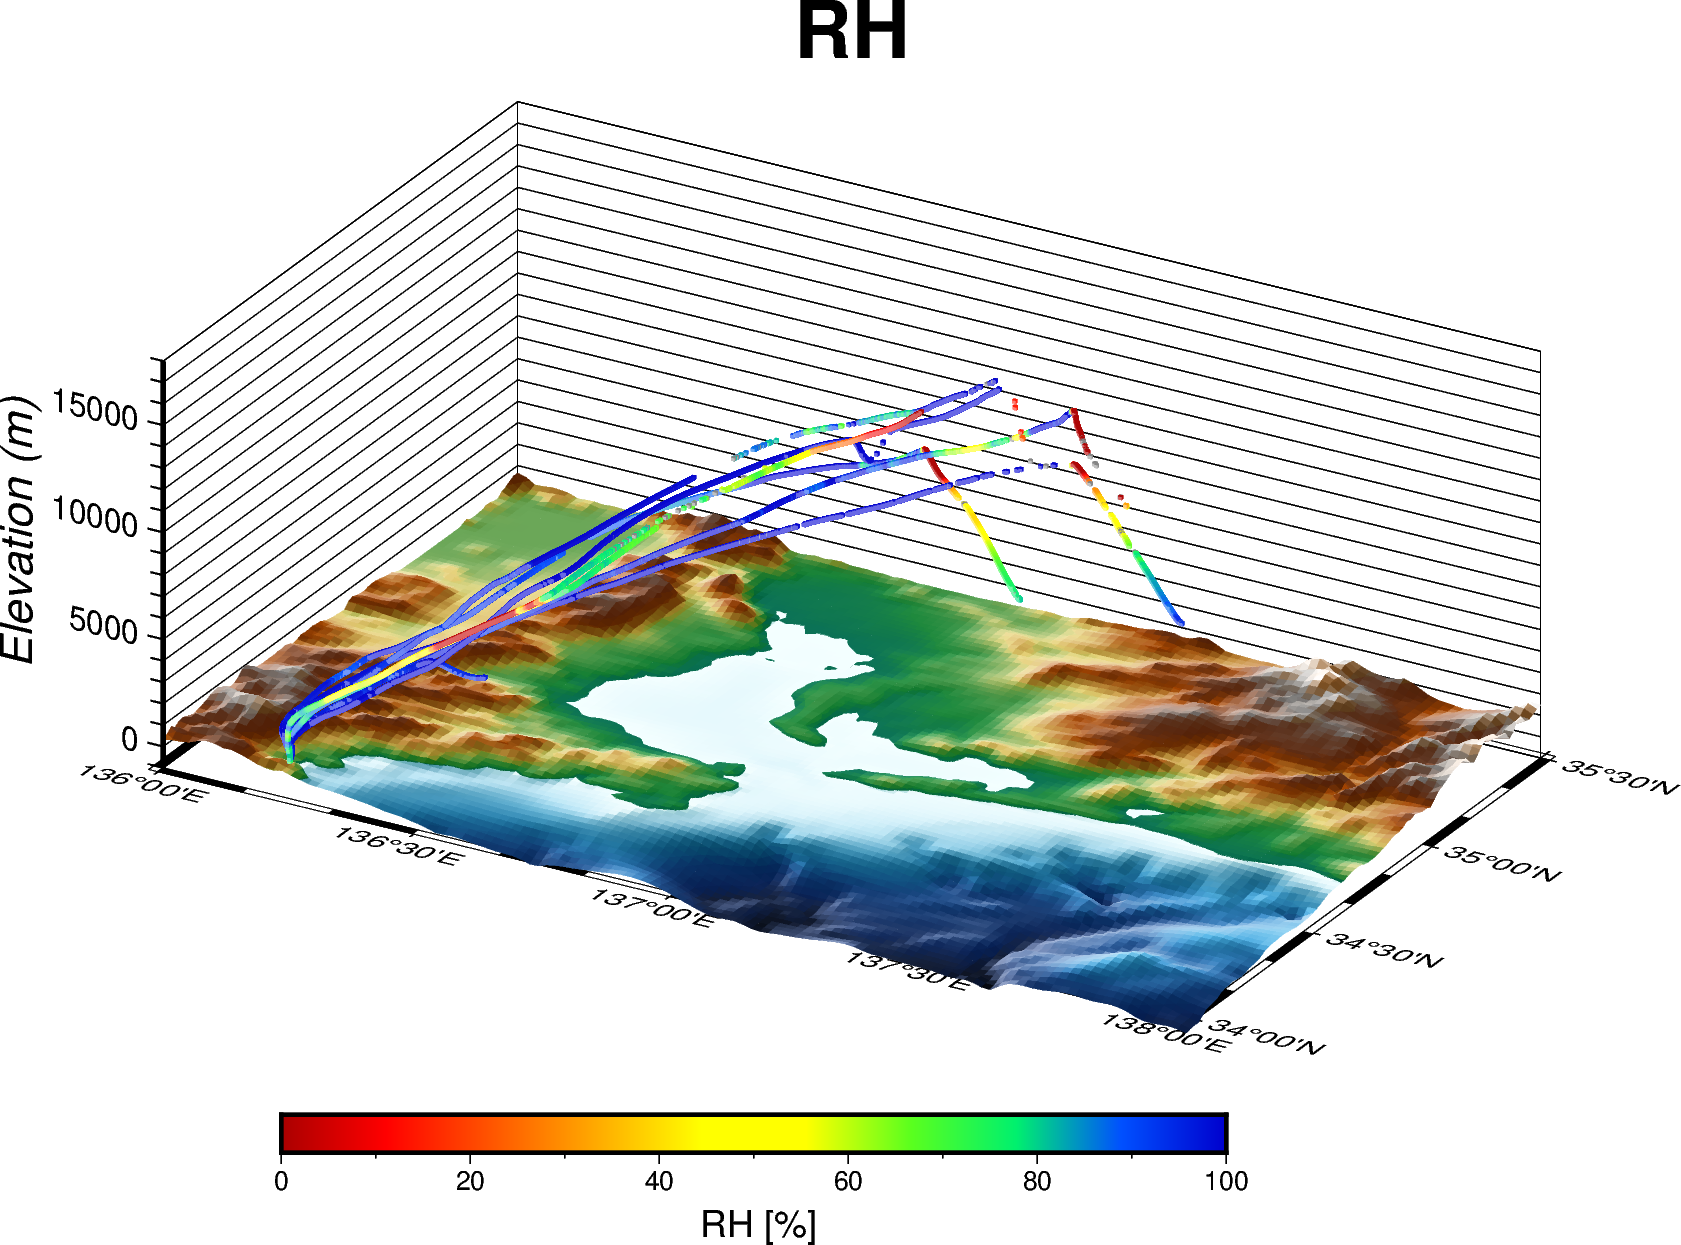

In [5]:
grid = pygmt.datasets.load_earth_relief(
        resolution="01m",
        region=[LON_MIN,LON_MAX,LAT_MIN,LAT_MAX,Z_MIN,Z_MAX],
    )
fig = pygmt.Figure()

fig.grdview(
    grid=grid,
    perspective=[AZIMUTH, ELEV],
    region=[LON_MIN,LON_MAX,LAT_MIN,LAT_MAX,Z_MIN,Z_MAX],
    frame=["xaf", "yaf", "zafg1000+lElevation (m)", "+tRH"],
    shading=True,
    surftype="s",
    cmap="geo",
    projection="X10c/6c",
    zscale=0.0002,
)

pygmt.makecpt(cmap="seis", series=[0, 100])

for st_name, [sonde, _] in data.items():
    fig.plot3d(
            x=sonde.lon,
            y=sonde.lat,
            z=sonde.z,
            style="u0.03c",
            fill=sonde.rh,
            cmap=True,
            perspective=[AZIMUTH, ELEV],
            zscale=0.0002,
        )
with fig.shift_origin(xshift=0):
    fig.colorbar(frame="xaf+l RH [%]")

fig.show()

## Animation of 3D trajectories over time

In [6]:
START_TIME = datetime(2024,6,18,6)  # plot start time
END_TIME = datetime(2024,6,18,16)   # plot end time
FRAME_DELTA_TIME = timedelta(minutes=10) # time interval between frames
PLOT_DELTA_TIME= timedelta(minutes=20)  # time range for each frame

In [7]:
time_list = []
time = START_TIME
while time <= END_TIME:
    time_list.append(time)
    time += FRAME_DELTA_TIME

plot_valid_time = START_TIME

images = []
for i,plot_valid_time in enumerate(tqdm(time_list)):
    # frame loop

    grid = pygmt.datasets.load_earth_relief(
        resolution="01m",
        region=[LON_MIN,LON_MAX,LAT_MIN,LAT_MAX,Z_MIN,Z_MAX],
    )
    fig = pygmt.Figure()

    fig.grdview(
        grid=grid,
        perspective=[AZIMUTH, ELEV],
        region=[LON_MIN,LON_MAX,LAT_MIN,LAT_MAX,Z_MIN,Z_MAX],
        frame=["xaf", "yaf", "zafg1000+lElevation (m)", f"+tRH {plot_valid_time:%Y-%m-%d %H:%M}"],
        shading=True,
        surftype="s",
        cmap="geo",
        projection="X10c/6c",
        zscale=0.0002,
    )

    pygmt.makecpt(cmap="seis", series=[0, 100])        
    
    for st_name, [sonde, _] in data.items():
        mask = (plot_valid_time - PLOT_DELTA_TIME <= sonde.df["Time"]) & (
            sonde.df["Time"] <= plot_valid_time
        )
        if np.nansum(mask) == 0:
            continue
        fig.plot3d(
                x=sonde.lon[mask],
                y=sonde.lat[mask],
                z=sonde.z[mask],
                style="u0.03c",
                fill=sonde.rh[mask],
                cmap=True,
                perspective=[AZIMUTH, ELEV],
                zscale=0.0002,
            )
    
    with fig.shift_origin(xshift=0):
        fig.colorbar(frame="xaf+l RH [%]")

    with tempfile.NamedTemporaryFile(suffix=".png") as tmp:
        fig.savefig(tmp.name)
        tmp.flush()

        images.append(imageio.imread(tmp.name))

imageio.mimsave("trj3d_animation.gif", images, fps=5, loop=0)

100%|██████████| 61/61 [00:24<00:00,  2.46it/s]


In [9]:
HTML('<img src="trj3d_animation.gif">')